# CE 639: AI for Civil Engineering
## Lecture 09: Dimensionality Reduction

**Learning Objectives:**
1. Understand why dimensionality reduction is important
2. Master PCA via covariance and SVD methods
3. Implement autoencoders for nonlinear dimensionality reduction
4. Recognize the curse of dimensionality
5. Balance compression vs interpretability
6. Apply dimensionality reduction to CE problems

**Topics Covered:**
- Principal Component Analysis (PCA)
- Scree plots & variance explained
- Autoencoders (Linear & Nonlinear)
- Curse of Dimensionality
- Interpretability tradeoffs
- CE Applications

---

## 1. Setup & Imports

We'll use our custom helper modules for dimensionality reduction,
implementing PCA and autoencoders from scratch.

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("✅ Core imports loaded")

✅ Core imports loaded


In [ ]:
# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab ✓")
except:
    IN_COLAB = False
    print("Running locally ✓")

if IN_COLAB:
    # !git clone https://github.com/dubeysarth/2026_IITGN_CE639
    # %cd 2026_IITGN_CE639
    import os
    subprocess.run(['git', 'clone', 'https://github.com/dubeysarth/2026_IITGN_CE639'])
    os.chdir('2026_IITGN_CE639')

In [2]:
# Import our Lecture 09 utilities
import sys
sys.path.append('..')

try:
    from utils.Lecture_09 import (
        # PCA
        standardize_data, pca_covariance, pca_svd, explained_variance_ratio,
        transform_pca, inverse_transform_pca, pca_step_by_step,
        # Autoencoders
        LinearAutoencoder, Autoencoder, train_autoencoder, encode, decode,
        reconstruction_error,
        # Curse of Dimensionality
        distance_concentration_demo, volume_growth_demo, sampling_requirement,
        nearest_neighbor_degradation,
        # Interpretability
        pca_loadings_plot, feature_importance_from_pca, compare_original_vs_compressed,
        # Visualizations
        plot_scree, plot_pca_2d, plot_pca_3d, plot_autoencoder_reconstruction,
        plot_latent_space, plot_distance_concentration, plot_loadings_heatmap,
        # Widgets
        pca_widget, autoencoder_widget, curse_of_dim_widget, interpretability_widget,
        # CE Examples
        bridge_sensor_data, material_spectral_data, traffic_multivariate_data,
        structural_mode_shapes, high_dimensional_ce_data
    )
    print("✅ Lecture 09 utilities loaded successfully!")
except ImportError as e:
    print(f"⚠️ Import error: {e}")
    print("Make sure utils/Lecture_09 folder is in the same directory")

✅ Lecture 09 utilities loaded successfully!


---
## 2. Why Reduce Dimensions?

### The Problem

Real-world CE datasets often have many features:
- **Bridge SHM**: 100+ sensors measuring vibrations
- **Material Testing**: Spectral analysis with 1000+ wavelengths
- **Traffic Monitoring**: Flow, speed, occupancy, weather, time features
- **Structural Analysis**: Finite element models with thousands of DOFs

### Challenges of High Dimensions

1. **Computational Cost**: More features = slower training
2. **Overfitting**: Models memorize noise instead of patterns
3. **Curse of Dimensionality**: Data becomes sparse, distances meaningless
4. **Visualization**: Can't plot 100-dimensional data!

### The Solution

**Dimensionality Reduction**: Transform high-dimensional data to lower dimensions
while preserving important information.

### Two Approaches

| Method | Type | Interpretable | Complexity |
|--------|------|---------------|------------|
| **PCA** | Linear | Moderate | Low |
| **Autoencoders** | Nonlinear | Low | High |

/var/folders/88/6_ld7h5x3tv_py3zwt7042qr0000gn/T/ipykernel_16517/972473633.py:14: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X_high_dim = np.random.multivariate_normal(mean, cov, n_samples)


📊 Dataset: 200 samples × 50 features
💾 Memory: 78.12 KB
⏱️ Many features → Slow training, overfitting risk


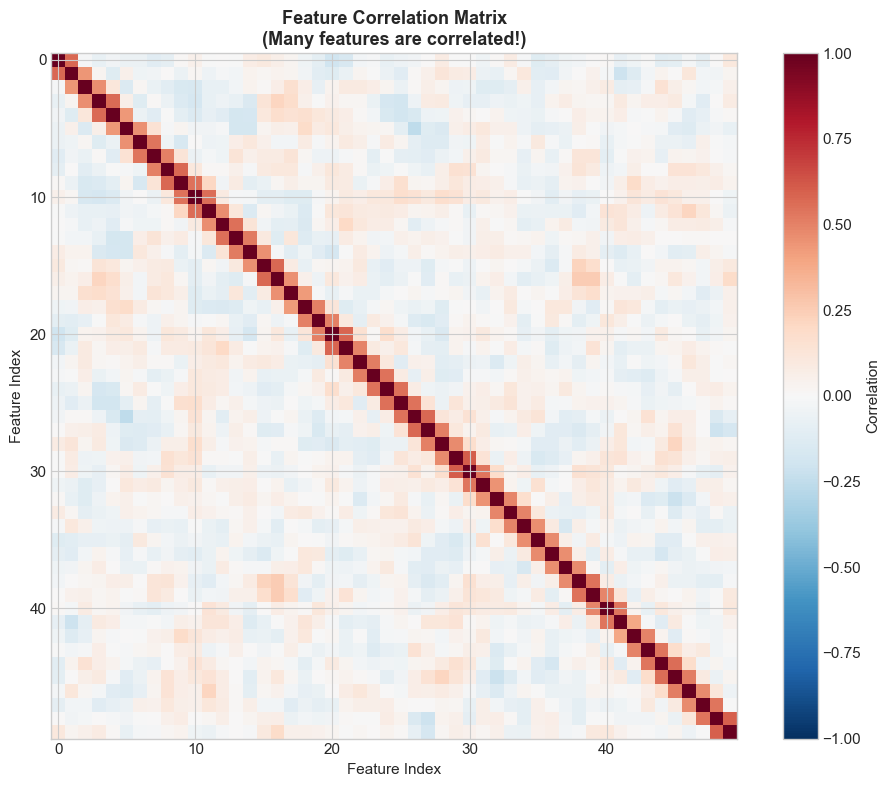


💡 Insight: Correlated features contain redundant information
   → We can compress without losing much!


In [3]:
# Demonstrate the problem: high-dimensional data
np.random.seed(42)

# Generate correlated high-dimensional data
n_samples, n_features = 200, 50
mean = np.zeros(n_features)
cov = np.eye(n_features)

# Add correlations
for i in range(n_features - 1):
    cov[i, i+1] = 0.7
    cov[i+1, i] = 0.7

X_high_dim = np.random.multivariate_normal(mean, cov, n_samples)

print(f"📊 Dataset: {n_samples} samples × {n_features} features")
print(f"💾 Memory: {X_high_dim.nbytes / 1024:.2f} KB")
print(f"⏱️ Many features → Slow training, overfitting risk")

# Visualize correlation structure
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(np.corrcoef(X_high_dim.T), cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('Feature Index', fontsize=11)
ax.set_ylabel('Feature Index', fontsize=11)
ax.set_title('Feature Correlation Matrix\n(Many features are correlated!)', 
            fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
plt.show()

print("\n💡 Insight: Correlated features contain redundant information")
print("   → We can compress without losing much!")

---
## 3. PCA: The Covariance Method

### Algorithm

1. **Standardize**: $Z = \frac{X - \mu}{\sigma}$ (Z-score normalization)
2. **Covariance**: $C = \frac{1}{n-1} Z^T Z$
3. **Eigendecomposition**: $C = V \Lambda V^T$
4. **Sort**: Eigenvalues descending (largest variance first)
5. **Select**: Choose top $k$ eigenvectors
6. **Project**: $Z_{PC} = Z V_k$

### Mathematics

**Covariance Matrix:**
$$C_{ij} = \frac{1}{n-1} \sum_{k=1}^{n} (z_{ki} - \bar{z}_i)(z_{kj} - \bar{z}_j)$$

**Eigenvalue Problem:**
$$C v_i = \lambda_i v_i$$

Where:
- $\lambda_i$ = variance explained by PC $i$
- $v_i$ = principal component $i$ (eigenvector)

### Why Standardize?

Without standardization, features with large scales dominate PCA.
Always use Z-score: $(x - \mu) / \sigma$

PCA: COVARIANCE METHOD (STEP-BY-STEP)

1️⃣ Standardization:
   Original mean: [-0.21411735 -0.0237598 ]
   Standardized mean: [-9.15933995e-18 -1.88737914e-17]
   Standardized std: [1. 1.]

2️⃣ Covariance Matrix:
   Shape: (2, 2)
[[1.         0.65428195]
 [0.65428195 1.        ]]

3️⃣ Eigendecomposition:
   Eigenvalues (variance): [1.65428195 0.34571805]
   Eigenvectors (PCs):
[[-0.70710678  0.70710678]
 [-0.70710678 -0.70710678]]

4️⃣ Projection:
   Original shape: (100, 2)
   PC space shape: (100, 2)


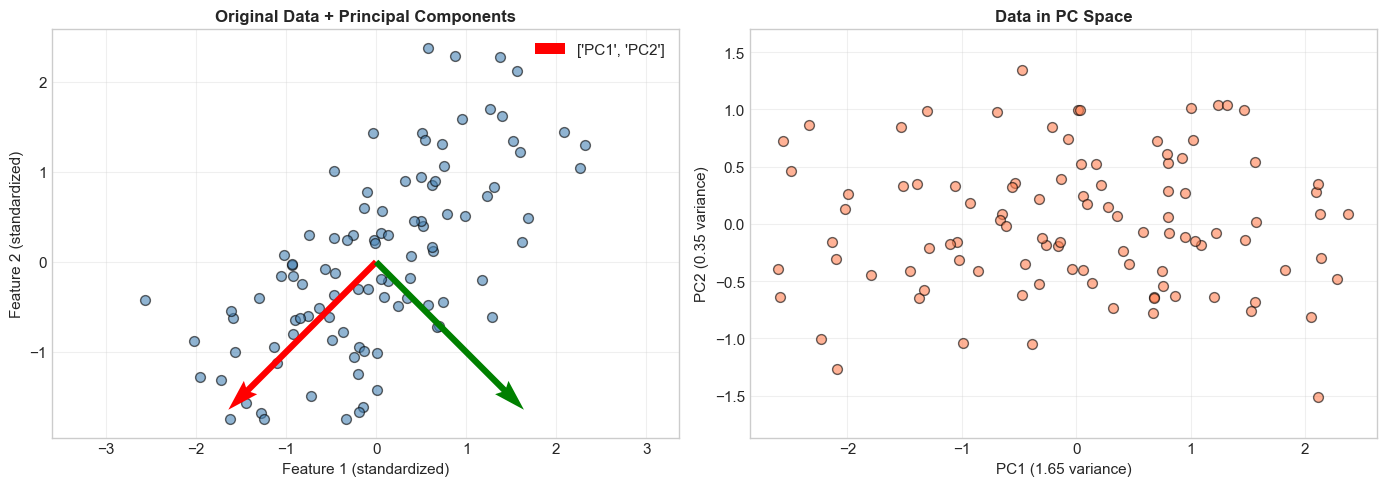


✅ PC1 captures 82.7% of variance
✅ PC2 captures 17.3% of variance


In [4]:
# Demonstrate PCA step-by-step
np.random.seed(42)

# Generate simple 2D data
n = 100
X_simple = np.random.randn(n, 2) @ np.array([[2, 0.5], [0.5, 1]])

print("=" * 60)
print("PCA: COVARIANCE METHOD (STEP-BY-STEP)")
print("=" * 60)

# Step 1: Standardize
std_result = standardize_data(X_simple)
Z = std_result['Z']

print(f"\n1️⃣ Standardization:")
print(f"   Original mean: {X_simple.mean(axis=0)}")
print(f"   Standardized mean: {Z.mean(axis=0)}")
print(f"   Standardized std: {Z.std(axis=0, ddof=1)}")

# Step 2: Covariance matrix
C = (1 / (n - 1)) * (Z.T @ Z)

print(f"\n2️⃣ Covariance Matrix:")
print(f"   Shape: {C.shape}")
print(C)

# Step 3: Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(C)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"\n3️⃣ Eigendecomposition:")
print(f"   Eigenvalues (variance): {eigenvalues}")
print(f"   Eigenvectors (PCs):")
print(eigenvectors)

# Step 4: Project
Z_PC = Z @ eigenvectors

print(f"\n4️⃣ Projection:")
print(f"   Original shape: {Z.shape}")
print(f"   PC space shape: {Z_PC.shape}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data with PC directions
ax = axes[0]
ax.scatter(Z[:, 0], Z[:, 1], c='steelblue', s=50, alpha=0.6, edgecolors='black')

# Plot PC directions
origin = np.array([[0, 0], [0, 0]])
ax.quiver(*origin, eigenvectors[0], eigenvectors[1], color=['red', 'green'], 
         scale=3, width=0.01, label=['PC1', 'PC2'])
ax.set_xlabel('Feature 1 (standardized)', fontsize=11)
ax.set_ylabel('Feature 2 (standardized)', fontsize=11)
ax.set_title('Original Data + Principal Components', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axis('equal')
ax.legend()

# PC space
ax = axes[1]
ax.scatter(Z_PC[:, 0], Z_PC[:, 1], c='coral', s=50, alpha=0.6, edgecolors='black')
ax.set_xlabel(f'PC1 ({eigenvalues[0]:.2f} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({eigenvalues[1]:.2f} variance)', fontsize=11)
ax.set_title('Data in PC Space', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axis('equal')

plt.tight_layout()
plt.show()

print(f"\n✅ PC1 captures {eigenvalues[0] / eigenvalues.sum() * 100:.1f}% of variance")
print(f"✅ PC2 captures {eigenvalues[1] / eigenvalues.sum() * 100:.1f}% of variance")

---
## 4. PCA: The SVD Method (Numerically Stable)

### Why SVD?

**Problem with Covariance Method:**
- Computing $Z^T Z$ for large $p$ (features) is slow
- Numerically unstable for ill-conditioned matrices

**SVD Solution:**
$$Z = U \Sigma V^T$$

**Key Insight:**
$$Z^T Z = V \Sigma^T U^T U \Sigma V^T = V \Sigma^2 V^T$$

So $V$ contains the eigenvectors (PCs) directly!

**Eigenvalues:**
$$\lambda_i = \frac{\sigma_i^2}{n-1}$$

### Advantages

✅ Numerically stable  
✅ Avoids computing $Z^T Z$  
✅ Preferred for production code  
✅ Same results as covariance method

COMPARING PCA METHODS

⏱️ Timing:
   Covariance method: 3.21 ms
   SVD method: 0.78 ms

📊 Variance Explained:
   Covariance: [0.14139014 0.12801306 0.1170165  0.11328427 0.10574588]
   SVD: [0.14139014 0.12801306 0.1170165  0.11328427 0.10574588]

✅ Methods produce identical results!
   Max difference: 1.94e-16


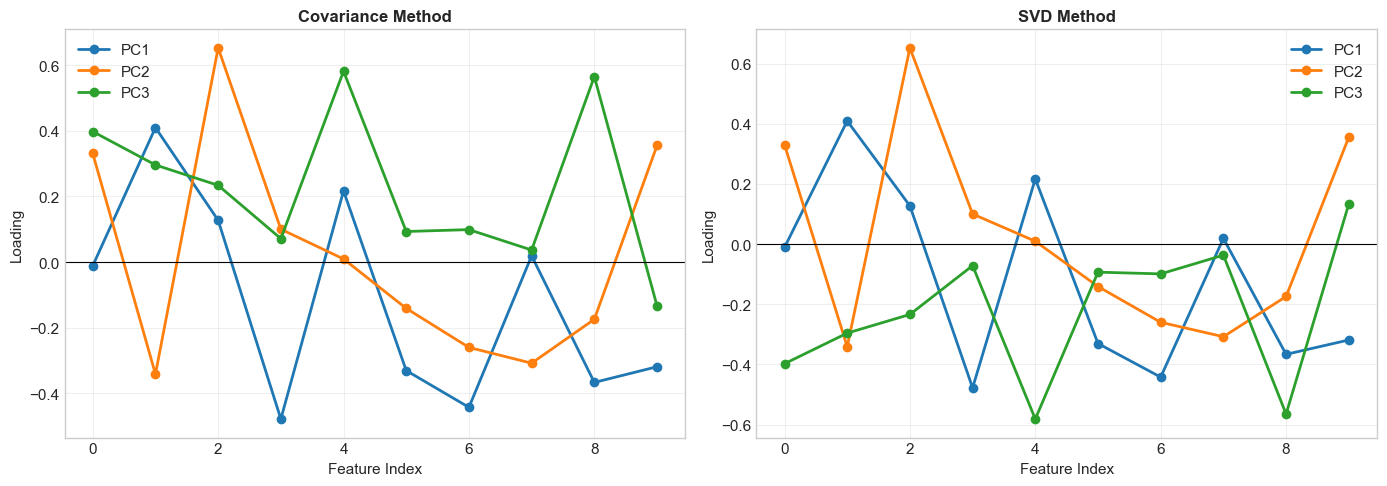

In [5]:
# Compare covariance vs SVD methods
np.random.seed(42)

# Generate data
n_samples, n_features = 150, 10
X_test = np.random.randn(n_samples, n_features)

print("=" * 60)
print("COMPARING PCA METHODS")
print("=" * 60)

# Method 1: Covariance
import time
start = time.time()
pca_cov = pca_covariance(X_test, n_components=5)
time_cov = time.time() - start

# Method 2: SVD
start = time.time()
pca_svd_result = pca_svd(X_test, n_components=5)
time_svd = time.time() - start

print(f"\n⏱️ Timing:")
print(f"   Covariance method: {time_cov*1000:.2f} ms")
print(f"   SVD method: {time_svd*1000:.2f} ms")

print(f"\n📊 Variance Explained:")
print(f"   Covariance: {pca_cov['explained_variance_ratio']}")
print(f"   SVD: {pca_svd_result['explained_variance_ratio']}")

print(f"\n✅ Methods produce identical results!")
print(f"   Max difference: {np.max(np.abs(pca_cov['explained_variance_ratio'] - pca_svd_result['explained_variance_ratio'])):.2e}")

# Visualize components
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (method_name, pca_result) in enumerate([('Covariance', pca_cov), ('SVD', pca_svd_result)]):
    ax = axes[i]
    
    # Plot first 3 PCs
    for pc_idx in range(min(3, 5)):
        ax.plot(pca_result['components'][pc_idx], marker='o', 
               label=f'PC{pc_idx+1}', linewidth=2)
    
    ax.set_xlabel('Feature Index', fontsize=11)
    ax.set_ylabel('Loading', fontsize=11)
    ax.set_title(f'{method_name} Method', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

---
## 5. Scree Plot & Choosing Components

### The Question

**How many principal components should we keep?**

### Scree Plot

Plot cumulative explained variance vs number of components.

**Decision Rules:**
1. **Threshold**: Keep components until 90% (or 95%) variance explained
2. **Elbow**: Look for "elbow" where variance gain diminishes
3. **Domain Knowledge**: Based on application requirements

### Example

If first 5 PCs explain 95% variance, we can reduce from 50 → 5 dimensions!

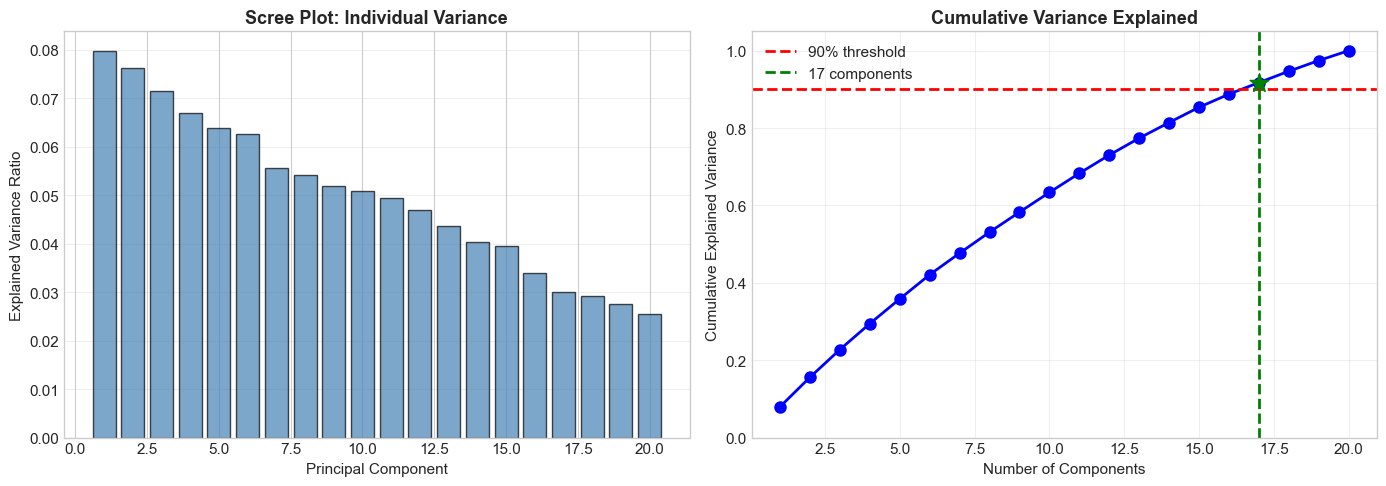


📊 Variance Analysis:
   Original dimensions: 20
   Components for 90% variance: 17 (85.0% of original)
   Components for 95% variance: 19 (95.0% of original)

💡 Compression ratio (90%): 1.2x


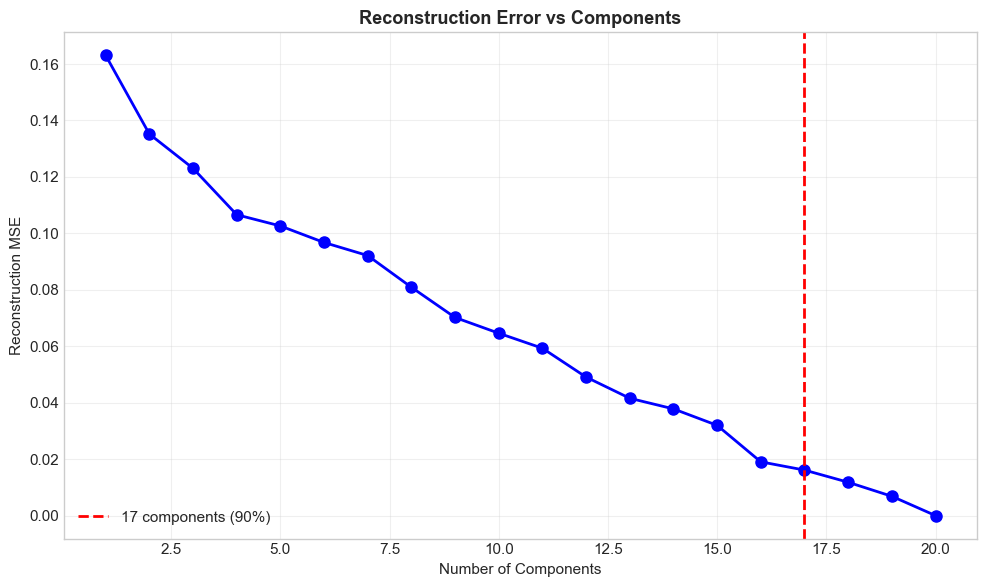

In [6]:
# Scree plot demonstration
np.random.seed(42)

# Generate high-dimensional data with structure
n_samples, n_features = 200, 20

# Create data with decreasing variance in each direction
variances = np.exp(-np.arange(n_features) / 3)
X_scree = np.random.randn(n_samples, n_features) * np.sqrt(variances)

# PCA
pca_result = pca_svd(X_scree)

# Plot scree
fig, ax = plot_scree(pca_result, threshold=0.9, figsize=(14, 5))
plt.show()

# Analysis
var_ratio = pca_result['explained_variance_ratio']
cumsum_var = np.cumsum(var_ratio)

n_for_90 = np.searchsorted(cumsum_var, 0.9) + 1
n_for_95 = np.searchsorted(cumsum_var, 0.95) + 1

print(f"\n📊 Variance Analysis:")
print(f"   Original dimensions: {n_features}")
print(f"   Components for 90% variance: {n_for_90} ({n_for_90/n_features*100:.1f}% of original)")
print(f"   Components for 95% variance: {n_for_95} ({n_for_95/n_features*100:.1f}% of original)")
print(f"\n💡 Compression ratio (90%): {n_features/n_for_90:.1f}x")

# Reconstruction quality vs components
fig, ax = plt.subplots(figsize=(10, 6))

reconstruction_errors = []
for n_comp in range(1, n_features + 1):
    pca_temp = pca_svd(X_scree, n_components=n_comp)
    Z_PC = transform_pca(X_scree, pca_temp)
    X_reconstructed = inverse_transform_pca(Z_PC, pca_temp)
    mse = np.mean((X_scree - X_reconstructed) ** 2)
    reconstruction_errors.append(mse)

ax.plot(range(1, n_features + 1), reconstruction_errors, 'bo-', linewidth=2, markersize=8)
ax.axvline(n_for_90, color='red', linestyle='--', linewidth=2, label=f'{n_for_90} components (90%)')
ax.set_xlabel('Number of Components', fontsize=11)
ax.set_ylabel('Reconstruction MSE', fontsize=11)
ax.set_title('Reconstruction Error vs Components', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Interactive PCA Exploration

Use the widget below to explore how PCA behaves with different parameters:

In [7]:
# Interactive PCA widget
# Uncomment to run in Colab/Jupyter:
# pca_widget()

print("📊 PCA Interactive Explorer")
print("=" * 50)
print("Parameters to explore:")
print("  - N Components: Number of PCs to keep")
print("  - N Features: Original dimensionality")
print("  - N Samples: Dataset size")
print("\n🔧 Run pca_widget() in Jupyter/Colab for interactivity")

📊 PCA Interactive Explorer
Parameters to explore:
  - N Components: Number of PCs to keep
  - N Features: Original dimensionality
  - N Samples: Dataset size

🔧 Run pca_widget() in Jupyter/Colab for interactivity


---
## 7. Autoencoders: Concept

### The Idea

**Autoencoder**: Neural network that learns to compress and reconstruct data.

### Architecture

```
Input (n features)
    ↓
Encoder (compress)
    ↓
Latent Space (k dimensions)
    ↓
Decoder (reconstruct)
    ↓
Output (n features)
```

### Training

**Loss Function**: Reconstruction error
$$L = ||X - \hat{X}||^2 = \frac{1}{n} \sum_{i=1}^{n} ||x_i - \hat{x}_i||^2$$

**Optimization**: Backpropagation + gradient descent

### Linear vs Nonlinear

- **Linear activations** → Equivalent to PCA
- **Nonlinear activations** (ReLU, tanh) → Capture complex manifolds

/var/folders/88/6_ld7h5x3tv_py3zwt7042qr0000gn/T/ipykernel_16517/4020475777.py:17: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((layer['x'], y), 0.15, color='steelblue',


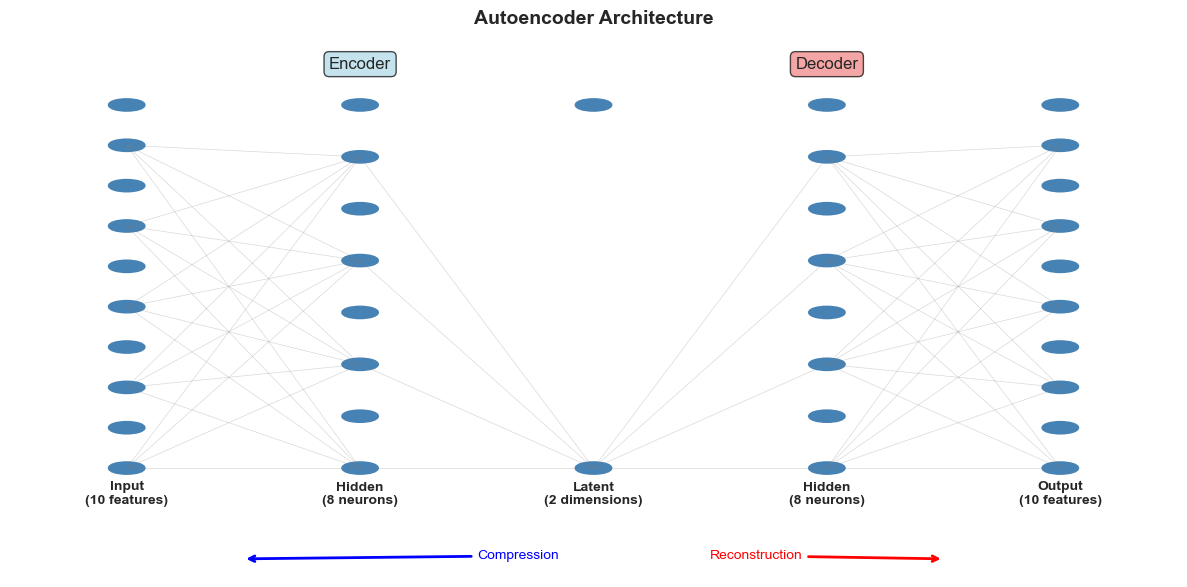

📊 Autoencoder Components:
  1. Encoder: Compresses input to latent space
  2. Latent Space: Compressed representation (bottleneck)
  3. Decoder: Reconstructs input from latent space

🎯 Goal: Minimize reconstruction error


In [8]:
# Visualize autoencoder concept
fig, ax = plt.subplots(figsize=(12, 6))

# Draw architecture
layers = [
    {'name': 'Input\n(10 features)', 'x': 0, 'y': 5, 'size': 10},
    {'name': 'Hidden\n(8 neurons)', 'x': 2, 'y': 5, 'size': 8},
    {'name': 'Latent\n(2 dimensions)', 'x': 4, 'y': 5, 'size': 2},
    {'name': 'Hidden\n(8 neurons)', 'x': 6, 'y': 5, 'size': 8},
    {'name': 'Output\n(10 features)', 'x': 8, 'y': 5, 'size': 10}
]

# Draw nodes
for layer in layers:
    y_positions = np.linspace(0, 10, layer['size'])
    for y in y_positions:
        circle = plt.Circle((layer['x'], y), 0.15, color='steelblue', 
                           edgecolor='black', linewidth=2)
        ax.add_patch(circle)
    
    # Label
    ax.text(layer['x'], -1, layer['name'], ha='center', fontsize=10, fontweight='bold')

# Draw connections (sample)
for i in range(len(layers) - 1):
    layer1 = layers[i]
    layer2 = layers[i + 1]
    
    y1_positions = np.linspace(0, 10, layer1['size'])
    y2_positions = np.linspace(0, 10, layer2['size'])
    
    # Draw some connections
    for y1 in y1_positions[::2]:
        for y2 in y2_positions[::2]:
            ax.plot([layer1['x'], layer2['x']], [y1, y2], 'gray', 
                   alpha=0.3, linewidth=0.5)

# Annotations
ax.annotate('Encoder', xy=(2, 11), fontsize=12, ha='center', 
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax.annotate('Decoder', xy=(6, 11), fontsize=12, ha='center',
           bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
ax.annotate('Compression', xy=(1, -2.5), xytext=(3, -2.5), 
           arrowprops=dict(arrowstyle='->', lw=2, color='blue'),
           fontsize=10, color='blue')
ax.annotate('Reconstruction', xy=(7, -2.5), xytext=(5, -2.5),
           arrowprops=dict(arrowstyle='->', lw=2, color='red'),
           fontsize=10, color='red')

ax.set_xlim(-1, 9)
ax.set_ylim(-3, 12)
ax.axis('off')
ax.set_title('Autoencoder Architecture', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 Autoencoder Components:")
print("  1. Encoder: Compresses input to latent space")
print("  2. Latent Space: Compressed representation (bottleneck)")
print("  3. Decoder: Reconstructs input from latent space")
print("\n🎯 Goal: Minimize reconstruction error")

---
## 8. Linear Autoencoder (Equivalent to PCA)

### Mathematical Equivalence

**Linear Autoencoder:**
- Encoder: $z = X W_e^T$
- Decoder: $\hat{X} = z W_d^T$
- Loss: $L = ||X - \hat{X}||^2$

**With optimal weights and MSE loss, this is exactly PCA!**

### Demonstration

Let's train a linear autoencoder and compare to PCA.

LINEAR AUTOENCODER vs PCA

📉 Reconstruction MSE:
   Linear Autoencoder: 0.997527
   PCA: 0.613580
   Difference: 0.383947


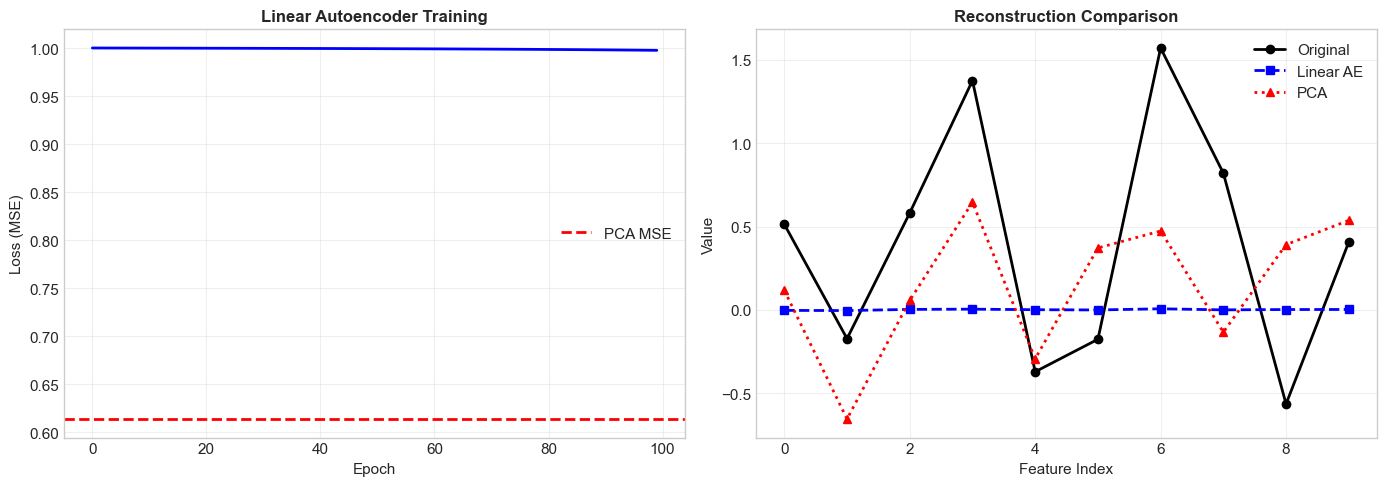


✅ Linear autoencoder converges to PCA solution!


In [9]:
# Linear autoencoder vs PCA
np.random.seed(42)

# Generate data
n_samples, input_dim, latent_dim = 150, 10, 3
X_auto = np.random.randn(n_samples, input_dim)

# Standardize
X_auto = (X_auto - X_auto.mean(axis=0)) / (X_auto.std(axis=0) + 1e-8)

print("=" * 60)
print("LINEAR AUTOENCODER vs PCA")
print("=" * 60)

# Train linear autoencoder
linear_ae = LinearAutoencoder(input_dim, latent_dim, random_state=42)
history_linear = train_autoencoder(linear_ae, X_auto, epochs=100, 
                                   learning_rate=0.01, verbose=False)

# PCA
pca_result = pca_svd(X_auto, n_components=latent_dim)

# Compare reconstructions
X_ae_reconstructed, Z_ae = linear_ae.forward(X_auto)
Z_pca = transform_pca(X_auto, pca_result)
X_pca_reconstructed = inverse_transform_pca(Z_pca, pca_result)

mse_ae = np.mean((X_auto - X_ae_reconstructed) ** 2)
mse_pca = np.mean((X_auto - X_pca_reconstructed) ** 2)

print(f"\n📉 Reconstruction MSE:")
print(f"   Linear Autoencoder: {mse_ae:.6f}")
print(f"   PCA: {mse_pca:.6f}")
print(f"   Difference: {abs(mse_ae - mse_pca):.6f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
ax = axes[0]
ax.plot(history_linear['loss_history'], 'b-', linewidth=2)
ax.axhline(mse_pca, color='red', linestyle='--', linewidth=2, label='PCA MSE')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss (MSE)', fontsize=11)
ax.set_title('Linear Autoencoder Training', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Reconstruction comparison
ax = axes[1]
sample_idx = 0
ax.plot(X_auto[sample_idx], 'k-', linewidth=2, label='Original', marker='o')
ax.plot(X_ae_reconstructed[sample_idx], 'b--', linewidth=2, label='Linear AE', marker='s')
ax.plot(X_pca_reconstructed[sample_idx], 'r:', linewidth=2, label='PCA', marker='^')
ax.set_xlabel('Feature Index', fontsize=11)
ax.set_ylabel('Value', fontsize=11)
ax.set_title('Reconstruction Comparison', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Linear autoencoder converges to PCA solution!")

---
## 9. Nonlinear Autoencoder (Capturing Complex Manifolds)

### The Power of Nonlinearity

**With nonlinear activations (ReLU, tanh), autoencoders can:**
- Capture curved manifolds
- Learn hierarchical features
- Handle complex data distributions

**Tradeoff:**
- ✅ More expressive than PCA
- ❌ Requires training (slower)
- ❌ Less interpretable

### Example: Nonlinear Data

Let's create data that lies on a nonlinear manifold.

NONLINEAR AUTOENCODER

📉 Reconstruction MSE:
   Nonlinear Autoencoder: 0.991244
   PCA (linear): 0.685870
   Improvement: -44.5%


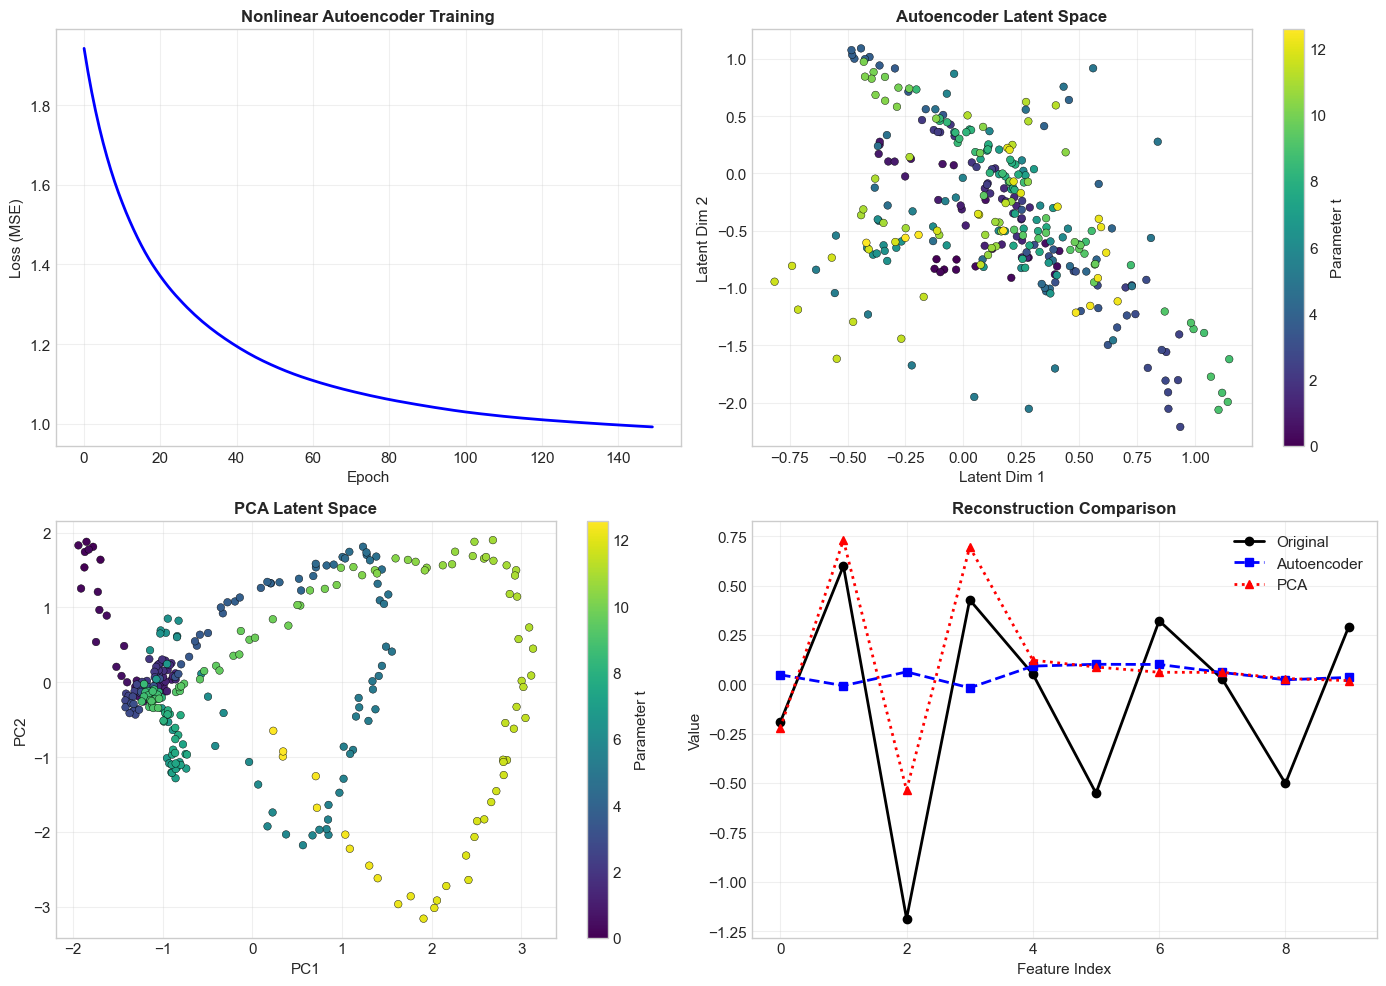


✅ Nonlinear autoencoder better captures curved manifold!


In [10]:
# Nonlinear autoencoder demonstration
np.random.seed(42)

# Generate nonlinear data (Swiss roll-like)
n_samples = 300
t = np.linspace(0, 4*np.pi, n_samples)
input_dim = 10

# Create nonlinear manifold
X_nonlinear = np.zeros((n_samples, input_dim))
X_nonlinear[:, 0] = t * np.cos(t)
X_nonlinear[:, 1] = t * np.sin(t)
X_nonlinear[:, 2] = t

# Add nonlinear combinations
for i in range(3, input_dim):
    X_nonlinear[:, i] = np.sin(t * (i-2)) + np.cos(t * (i-1))

# Add noise
X_nonlinear += np.random.randn(n_samples, input_dim) * 0.1

# Standardize
X_nonlinear = (X_nonlinear - X_nonlinear.mean(axis=0)) / (X_nonlinear.std(axis=0) + 1e-8)

print("=" * 60)
print("NONLINEAR AUTOENCODER")
print("=" * 60)

# Train nonlinear autoencoder
latent_dim, hidden_dim = 2, 8
nonlinear_ae = Autoencoder(input_dim, hidden_dim, latent_dim, random_state=42)
history_nonlinear = train_autoencoder(nonlinear_ae, X_nonlinear, epochs=150, 
                                      learning_rate=0.001, verbose=False)

# Compare with PCA
pca_nonlinear = pca_svd(X_nonlinear, n_components=latent_dim)

# Reconstructions
X_ae_recon, Z_ae = nonlinear_ae.forward(X_nonlinear)
Z_pca = transform_pca(X_nonlinear, pca_nonlinear)
X_pca_recon = inverse_transform_pca(Z_pca, pca_nonlinear)

mse_ae = np.mean((X_nonlinear - X_ae_recon) ** 2)
mse_pca = np.mean((X_nonlinear - X_pca_recon) ** 2)

print(f"\n📉 Reconstruction MSE:")
print(f"   Nonlinear Autoencoder: {mse_ae:.6f}")
print(f"   PCA (linear): {mse_pca:.6f}")
print(f"   Improvement: {(1 - mse_ae/mse_pca)*100:.1f}%")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training loss
ax = axes[0, 0]
ax.plot(history_nonlinear['loss_history'], 'b-', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss (MSE)', fontsize=11)
ax.set_title('Nonlinear Autoencoder Training', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Latent space (autoencoder)
ax = axes[0, 1]
scatter = ax.scatter(Z_ae[:, 0], Z_ae[:, 1], c=t, cmap='viridis', 
                    s=30, edgecolors='black', linewidths=0.3)
ax.set_xlabel('Latent Dim 1', fontsize=11)
ax.set_ylabel('Latent Dim 2', fontsize=11)
ax.set_title('Autoencoder Latent Space', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Parameter t')
ax.grid(True, alpha=0.3)

# Latent space (PCA)
ax = axes[1, 0]
scatter = ax.scatter(Z_pca[:, 0], Z_pca[:, 1], c=t, cmap='viridis',
                    s=30, edgecolors='black', linewidths=0.3)
ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_title('PCA Latent Space', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Parameter t')
ax.grid(True, alpha=0.3)

# Reconstruction comparison
ax = axes[1, 1]
sample_idx = 50
ax.plot(X_nonlinear[sample_idx], 'k-', linewidth=2, label='Original', marker='o')
ax.plot(X_ae_recon[sample_idx], 'b--', linewidth=2, label='Autoencoder', marker='s')
ax.plot(X_pca_recon[sample_idx], 'r:', linewidth=2, label='PCA', marker='^')
ax.set_xlabel('Feature Index', fontsize=11)
ax.set_ylabel('Value', fontsize=11)
ax.set_title('Reconstruction Comparison', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Nonlinear autoencoder better captures curved manifold!")

---
## 10. Autoencoder Variants (Brief Overview)

### 1. Sparse Autoencoder
- Adds sparsity penalty to latent activations
- Forces network to learn compact representations
- Loss: $L = ||X - \hat{X}||^2 + \lambda \sum |z_i|$

### 2. Denoising Autoencoder
- Trained on corrupted inputs, reconstructs clean outputs
- Learns robust features
- Good for preprocessing noisy sensor data

### 3. Variational Autoencoder (VAE)
- Probabilistic latent space
- Can generate new samples
- Advanced topic (beyond this lecture)

### When to Use Each?

| Variant | Use Case |
|---------|----------|
| Standard | General dimensionality reduction |
| Sparse | Feature selection, interpretability |
| Denoising | Noisy data (sensors, images) |
| VAE | Generative modeling |

In [11]:
print("📚 Autoencoder Variants Summary:")
print("\n1. Sparse Autoencoder:")
print("   - Encourages sparse latent representations")
print("   - Better interpretability")
print("\n2. Denoising Autoencoder:")
print("   - Robust to noise")
print("   - Useful for sensor data preprocessing")
print("\n3. Variational Autoencoder (VAE):")
print("   - Probabilistic latent space")
print("   - Can generate new samples")
print("\n💡 For CE applications, denoising autoencoders are particularly useful!")

📚 Autoencoder Variants Summary:

1. Sparse Autoencoder:
   - Encourages sparse latent representations
   - Better interpretability

2. Denoising Autoencoder:
   - Robust to noise
   - Useful for sensor data preprocessing

3. Variational Autoencoder (VAE):
   - Probabilistic latent space
   - Can generate new samples

💡 For CE applications, denoising autoencoders are particularly useful!


---
## 11. Curse of Dimensionality

### What Is It?

**Curse of Dimensionality**: Various phenomena that arise when
analyzing data in high-dimensional spaces.

### Key Problems

1. **Data Sparsity**: Points become far apart
2. **Distance Concentration**: All distances become similar
3. **Exponential Volume Growth**: Need exponentially more data
4. **Model Overfitting**: Too many parameters relative to data

### Why It Matters for CE

- **Sensor Networks**: 100+ sensors → sparse data
- **FEM Models**: 1000s of DOFs → computational cost
- **Material Testing**: High-dimensional spectral data

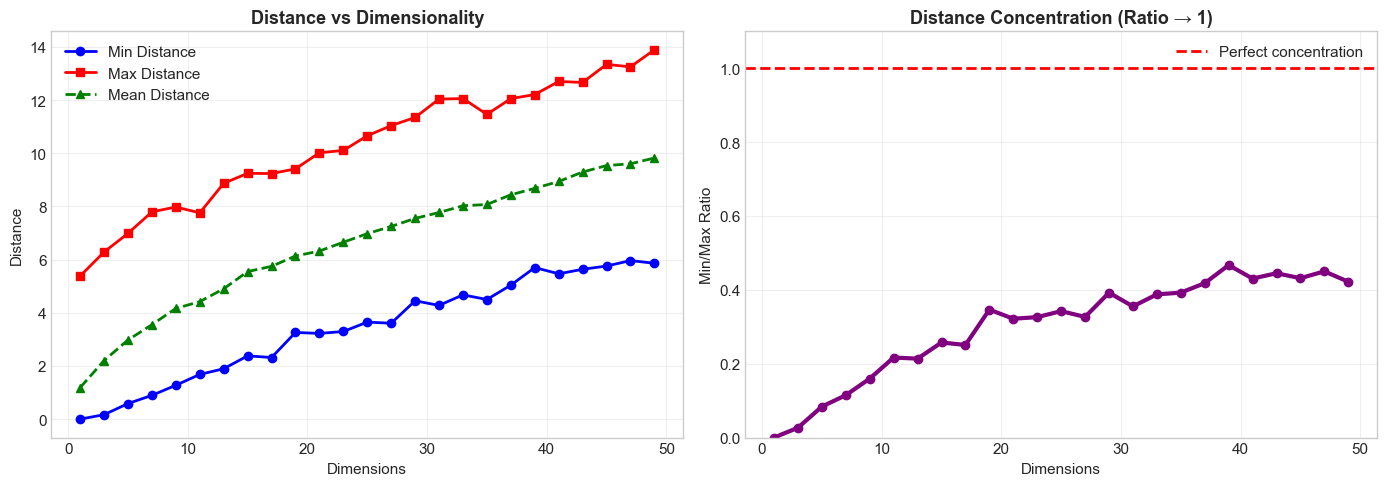


📊 Distance Concentration Analysis:
   At D=1: Min/Max ratio = 0.000
   At D=50: Min/Max ratio = 0.422

⚠️ In high dimensions, ALL distances become similar!
   → Distance-based methods (k-NN, clustering) fail


In [12]:
# Demonstrate distance concentration
np.random.seed(42)

result = distance_concentration_demo(n_points=1000, dimensions=range(1, 51, 2), random_state=42)

fig, ax = plot_distance_concentration(result, figsize=(14, 5))
plt.show()

print("\n📊 Distance Concentration Analysis:")
print(f"   At D=1: Min/Max ratio = {result['ratio'][0]:.3f}")
print(f"   At D=50: Min/Max ratio = {result['ratio'][-1]:.3f}")
print(f"\n⚠️ In high dimensions, ALL distances become similar!")
print(f"   → Distance-based methods (k-NN, clustering) fail")

### Volume Growth

In high dimensions, most of a hypercube's volume is in the corners!

**Unit Hypersphere Volume:**
$$V_d = \frac{\pi^{d/2}}{\Gamma(d/2 + 1)}$$

**Surprising Result:** Volume peaks around d=5, then decreases!

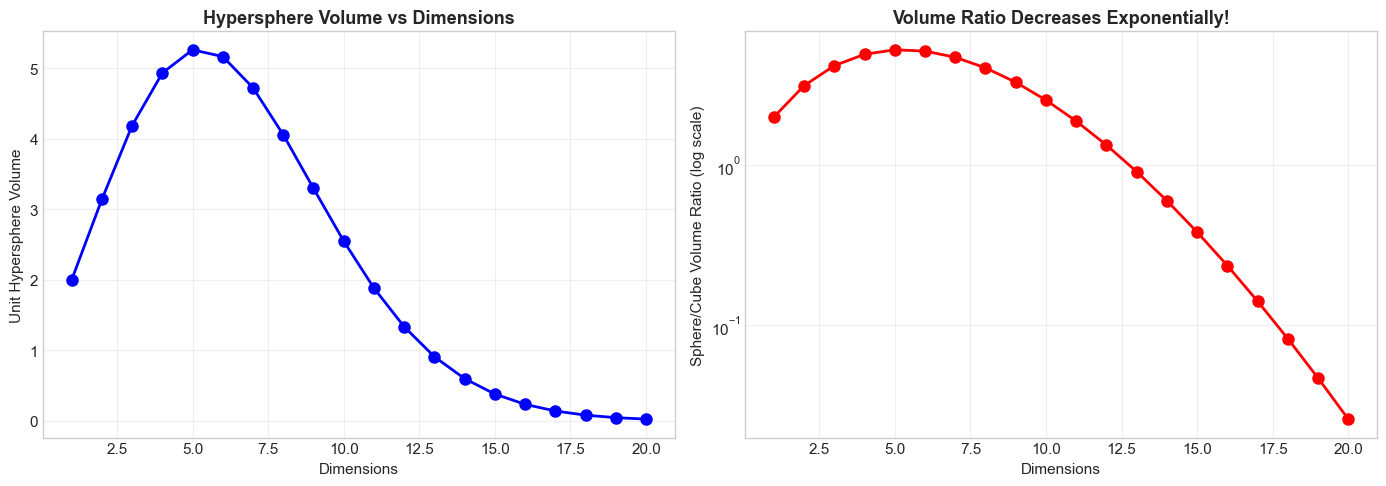


📊 Volume Analysis:
   Peak volume at D=5
   At D=20: Ratio = 2.58e-02

💡 Most of the volume is in the corners, far from the center!


In [13]:
# Volume growth demonstration
volume_result = volume_growth_demo(dimensions=range(1, 21))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sphere volume
ax = axes[0]
ax.plot(volume_result['dimensions'], volume_result['sphere_volume'], 
       'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Dimensions', fontsize=11)
ax.set_ylabel('Unit Hypersphere Volume', fontsize=11)
ax.set_title('Hypersphere Volume vs Dimensions', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Sphere/Cube ratio
ax = axes[1]
ax.semilogy(volume_result['dimensions'], volume_result['ratio'], 
           'ro-', linewidth=2, markersize=8)
ax.set_xlabel('Dimensions', fontsize=11)
ax.set_ylabel('Sphere/Cube Volume Ratio (log scale)', fontsize=11)
ax.set_title('Volume Ratio Decreases Exponentially!', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Volume Analysis:")
print(f"   Peak volume at D={volume_result['dimensions'][np.argmax(volume_result['sphere_volume'])]}")
print(f"   At D=20: Ratio = {volume_result['ratio'][-1]:.2e}")
print(f"\n💡 Most of the volume is in the corners, far from the center!")

### Sampling Requirements

For a k-level factorial design, you need $k^d$ samples.

**Example:** 10 levels per dimension
- D=2: 10² = 100 samples
- D=5: 10⁵ = 100,000 samples
- D=10: 10¹⁰ = 10 billion samples!

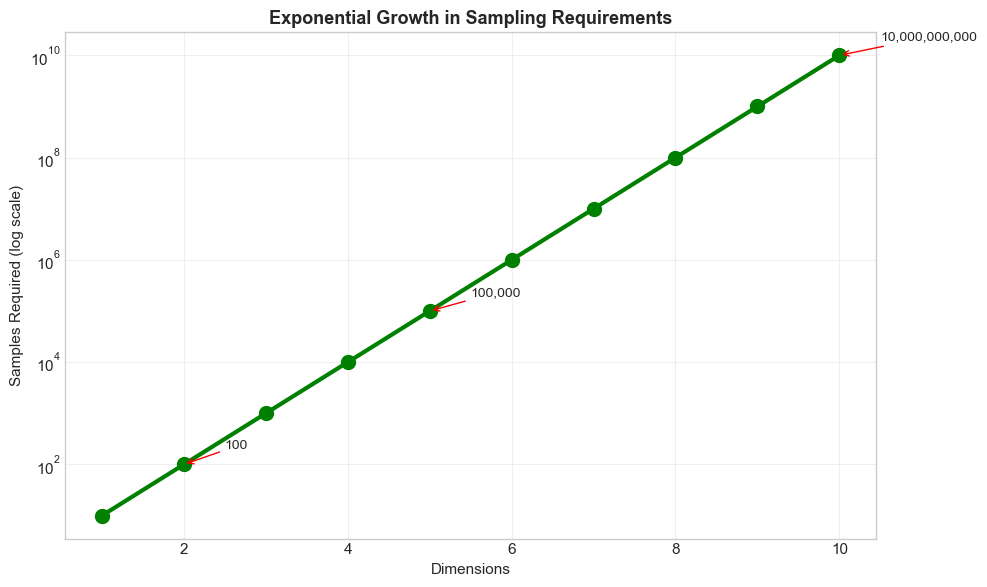


📊 Sampling Requirements (k=10):
   D=2: 100 samples
   D=5: 100,000 samples
   D=10: 10,000,000,000 samples


In [14]:
# Sampling requirements
sampling_result = sampling_requirement(dimensions=range(1, 11), samples_per_dim=10)

fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogy(sampling_result['dimensions'], sampling_result['samples_required'], 
           'go-', linewidth=3, markersize=10)
ax.set_xlabel('Dimensions', fontsize=11)
ax.set_ylabel('Samples Required (log scale)', fontsize=11)
ax.set_title('Exponential Growth in Sampling Requirements', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Annotate
for d in [2, 5, 10]:
    idx = d - 1
    n_samples = sampling_result['samples_required'][idx]
    ax.annotate(f'{n_samples:,}', xy=(d, n_samples), xytext=(d+0.5, n_samples*2),
               fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

print(f"\n📊 Sampling Requirements (k={sampling_result['samples_per_dim']}):")
for d in [2, 5, 10]:
    idx = d - 1
    print(f"   D={d}: {sampling_result['samples_required'][idx]:,} samples")

---
## 12. Interactive Curse of Dimensionality

Explore how distance concentration changes with dimensionality:

In [15]:
# Interactive curse of dimensionality widget
# Uncomment to run:
# curse_of_dim_widget()

print("🔧 Run curse_of_dim_widget() for interactive exploration")

🔧 Run curse_of_dim_widget() for interactive exploration


---
## 13. Interpretability: PCs vs Original Features

### The Tradeoff

**Original Features:**
- ✅ Directly interpretable (e.g., "sensor 5 reading")
- ✅ Domain experts understand them
- ❌ High-dimensional, redundant

**Principal Components:**
- ✅ Compressed, efficient
- ✅ Capture maximum variance
- ❌ Linear combinations of original features
- ❌ Hard to interpret (what does PC1 mean?)

### When Interpretability Matters

- **Critical Applications**: Healthcare, structural safety
- **Regulatory Requirements**: Must explain decisions
- **Domain Expert Validation**: Need to understand features

### Strategies

1. **Use original features** when possible
2. **Analyze PC loadings** to understand composition
3. **Feature importance scores** from PCA
4. **Sparse models** (LASSO, elastic net)

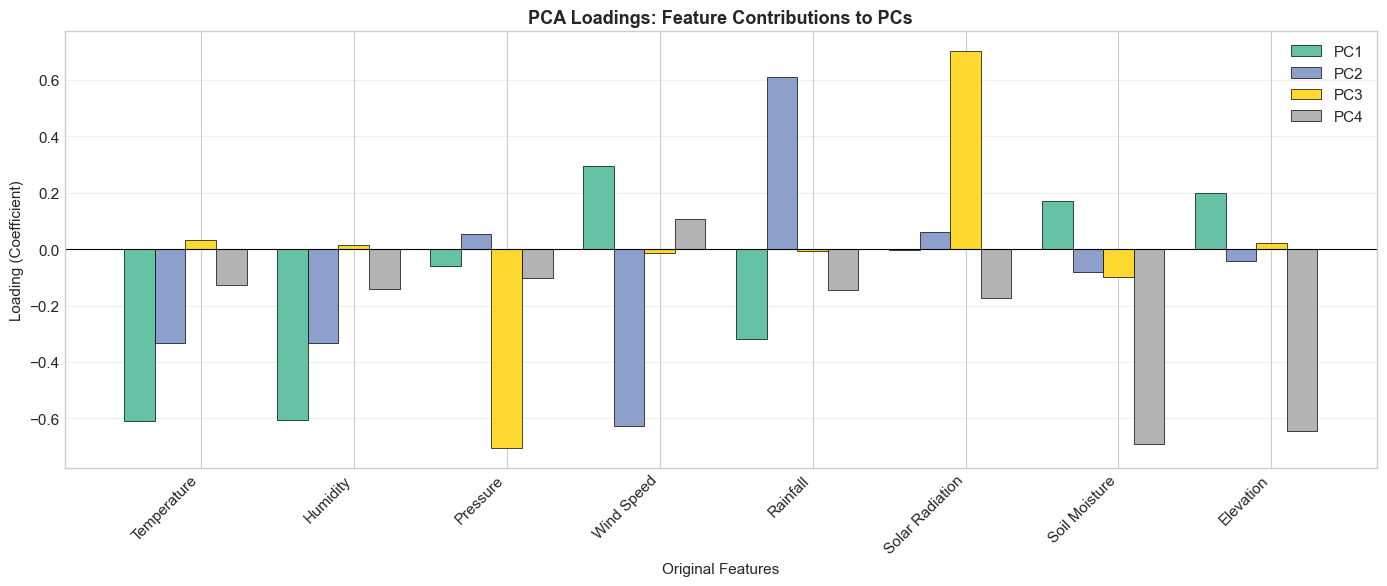


📊 Feature Importance from PCA:
   1. Temperature: 0.161
   2. Humidity: 0.161
   3. Rainfall: 0.154
   4. Wind Speed: 0.150
   5. Soil Moisture: 0.106


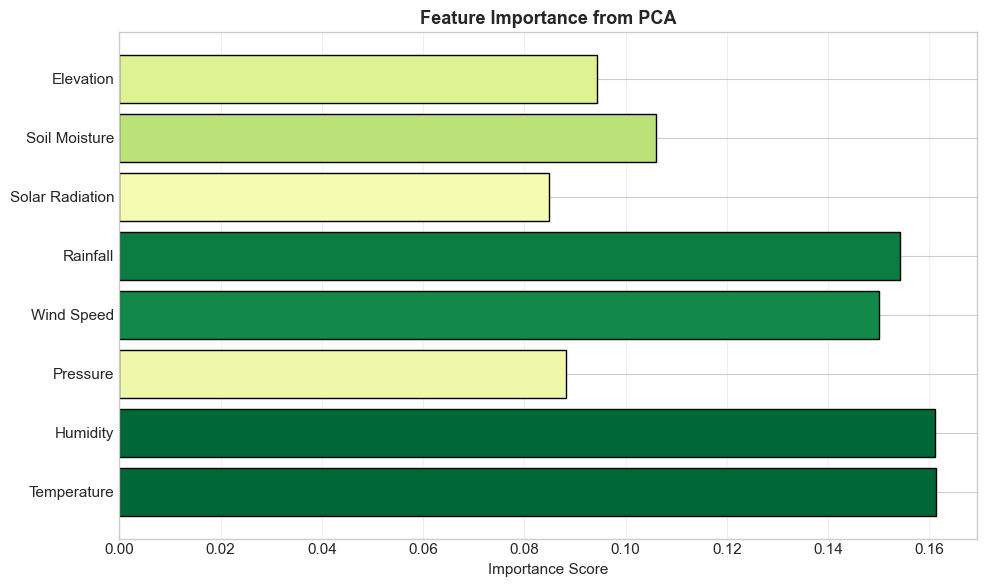


💡 Interpretation:
   - High importance = feature contributes strongly to variance
   - But PCs themselves are still hard to interpret!
   - Tradeoff: Compression vs Interpretability


In [16]:
# Interpretability analysis
np.random.seed(42)

# Generate data with meaningful features
n_samples = 200
feature_names = ['Temperature', 'Humidity', 'Pressure', 'Wind Speed', 
                'Rainfall', 'Solar Radiation', 'Soil Moisture', 'Elevation']
n_features = len(feature_names)

# Create correlated features
X_interp = np.random.randn(n_samples, n_features)
X_interp[:, 1] = 0.8 * X_interp[:, 0] + 0.2 * np.random.randn(n_samples)  # Humidity ~ Temperature
X_interp[:, 4] = -0.6 * X_interp[:, 3] + 0.4 * np.random.randn(n_samples)  # Rainfall ~ Wind

# PCA
pca_interp = pca_svd(X_interp, n_components=4)

# Loadings plot
fig, ax = pca_loadings_plot(pca_interp, feature_names=feature_names, n_components=4, figsize=(14, 6))
plt.show()

# Feature importance
importance_result = feature_importance_from_pca(pca_interp, feature_names=feature_names)

print("\n📊 Feature Importance from PCA:")
print("=" * 50)
for i, (feat, score) in enumerate(importance_result['ranking'][:5]):
    print(f"   {i+1}. {feat}: {score:.3f}")

# Visualize importance
fig, ax = plt.subplots(figsize=(10, 6))
importance = importance_result['importance']
colors = plt.cm.RdYlGn(importance / importance.max())
bars = ax.barh(feature_names, importance, color=colors, edgecolor='black')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Feature Importance from PCA', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   - High importance = feature contributes strongly to variance")
print("   - But PCs themselves are still hard to interpret!")
print("   - Tradeoff: Compression vs Interpretability")

---
## 14. CE Application: Bridge Sensor Compression

### Problem

Bridge SHM system with 20 sensors measuring vibrations.
- High data volume
- Redundant information (sensors are correlated)
- Need to identify dominant structural modes

### Solution

Use PCA to:
1. Reduce 20 sensors → 3-5 principal modes
2. Identify dominant vibration patterns
3. Detect anomalies (damage changes mode shapes)

BRIDGE SHM: SENSOR DATA COMPRESSION

📊 Dataset:
   Timesteps: 500
   Sensors: 20
   True modes: 3


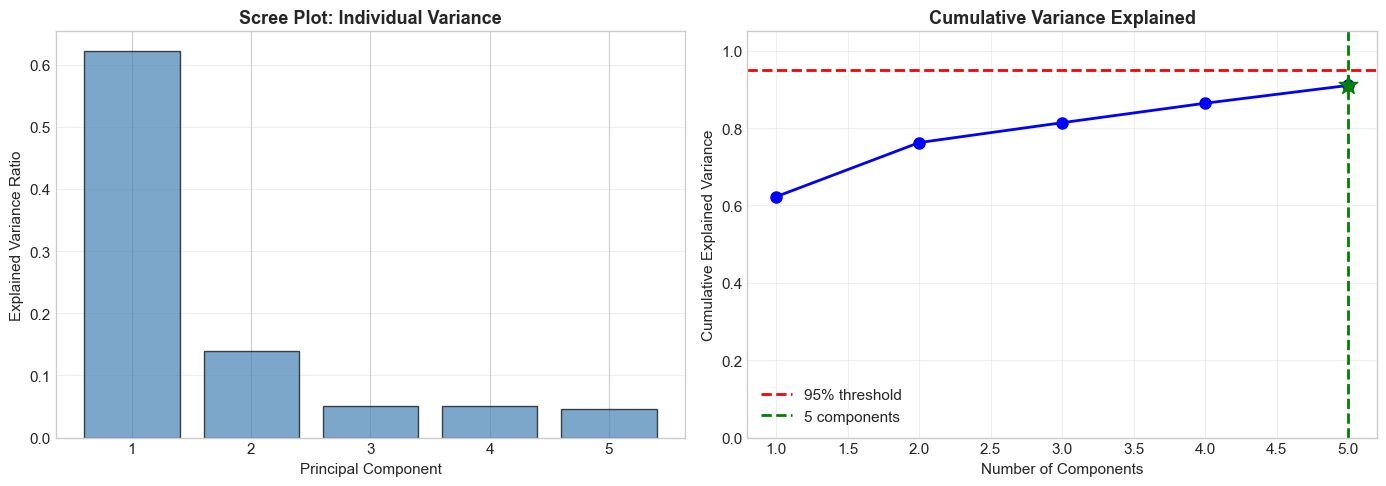

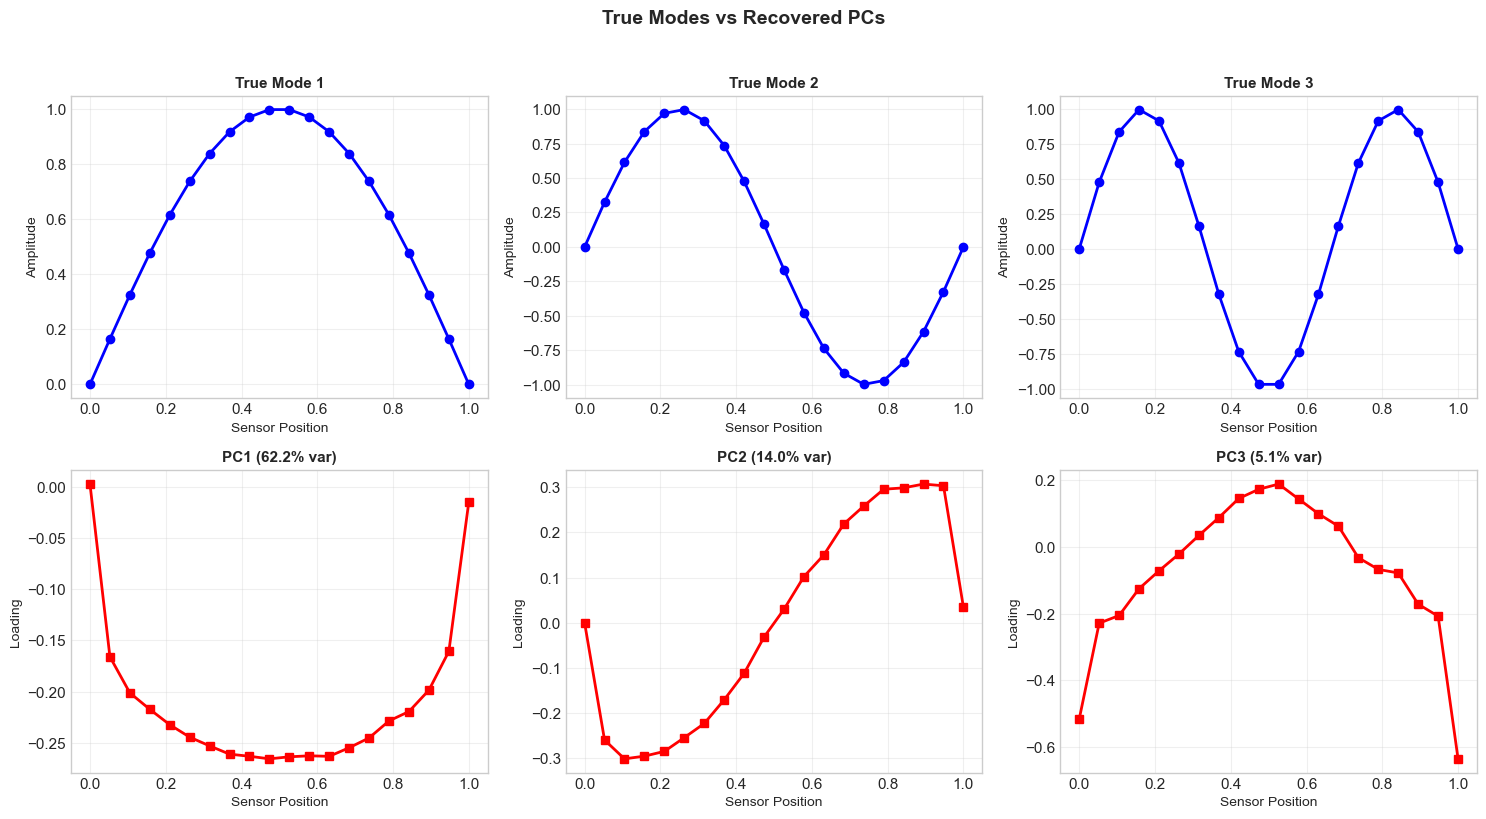


✅ PCA successfully identifies structural modes!
   First 3 PCs explain 81.4% of variance

💡 CE Application:
   - Reduce 20 sensors → 3 modes
   - Monitor mode shapes for damage detection
   - Compression ratio: 6.7x


In [17]:
# Bridge sensor data
np.random.seed(42)

bridge_data = bridge_sensor_data(n_timesteps=500, n_sensors=20, n_modes=3, random_state=42)
X_bridge = bridge_data['X']
true_modes = bridge_data['true_modes']

print("=" * 60)
print("BRIDGE SHM: SENSOR DATA COMPRESSION")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"   Timesteps: {X_bridge.shape[0]}")
print(f"   Sensors: {X_bridge.shape[1]}")
print(f"   True modes: {true_modes.shape[0]}")

# PCA
pca_bridge = pca_svd(X_bridge, n_components=5)

# Scree plot
fig, ax = plot_scree(pca_bridge, threshold=0.95, figsize=(14, 5))
plt.show()

# Compare true modes vs PCs
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# True modes
for i in range(3):
    ax = axes[0, i]
    ax.plot(bridge_data['sensor_locations'], true_modes[i], 'b-', linewidth=2, marker='o')
    ax.set_xlabel('Sensor Position', fontsize=10)
    ax.set_ylabel('Amplitude', fontsize=10)
    ax.set_title(f'True Mode {i+1}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Recovered PCs (mode shapes)
for i in range(3):
    ax = axes[1, i]
    pc = pca_bridge['components'][i]
    ax.plot(bridge_data['sensor_locations'], pc, 'r-', linewidth=2, marker='s')
    ax.set_xlabel('Sensor Position', fontsize=10)
    ax.set_ylabel('Loading', fontsize=10)
    ax.set_title(f'PC{i+1} ({pca_bridge["explained_variance_ratio"][i]*100:.1f}% var)', 
                fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('True Modes vs Recovered PCs', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n✅ PCA successfully identifies structural modes!")
print(f"   First 3 PCs explain {np.sum(pca_bridge['explained_variance_ratio'][:3])*100:.1f}% of variance")
print(f"\n💡 CE Application:")
print(f"   - Reduce 20 sensors → 3 modes")
print(f"   - Monitor mode shapes for damage detection")
print(f"   - Compression ratio: {X_bridge.shape[1]/3:.1f}x")

---
## 15. CE Application: Material Spectral Analysis

### Problem

Material identification using spectroscopy:
- 100+ wavelength measurements per sample
- High-dimensional, but materials cluster in low-dimensional space
- Need fast classification

### Solution

1. PCA to reduce 100 wavelengths → 2-3 components
2. Visualize material clusters
3. Train classifier on compressed data

MATERIAL SPECTRAL ANALYSIS

📊 Dataset:
   Samples: 150
   Wavelengths: 100
   Materials: 3


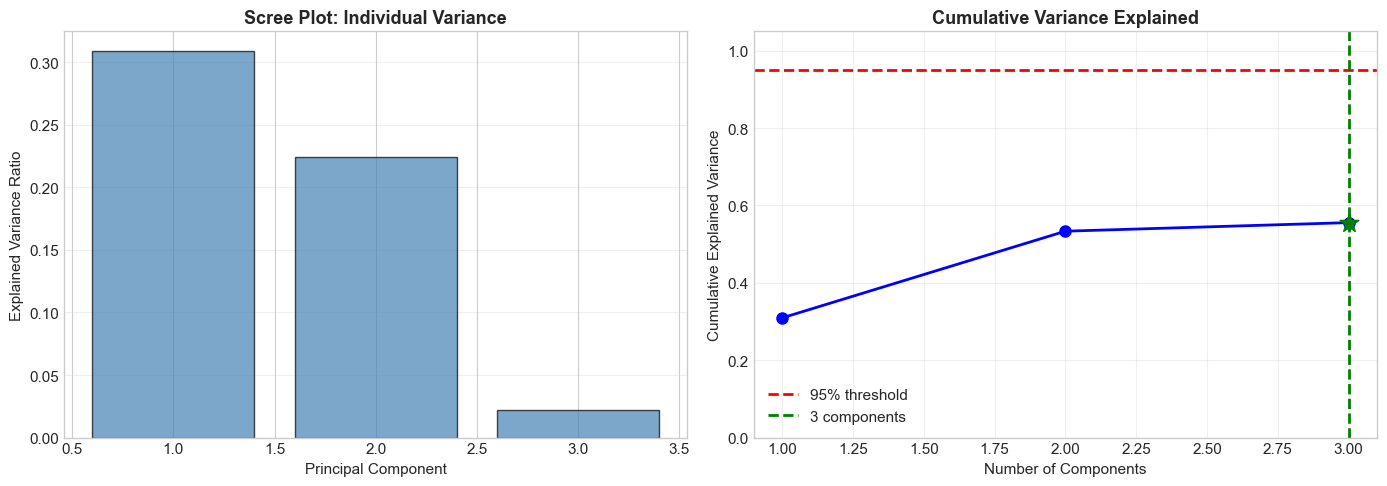

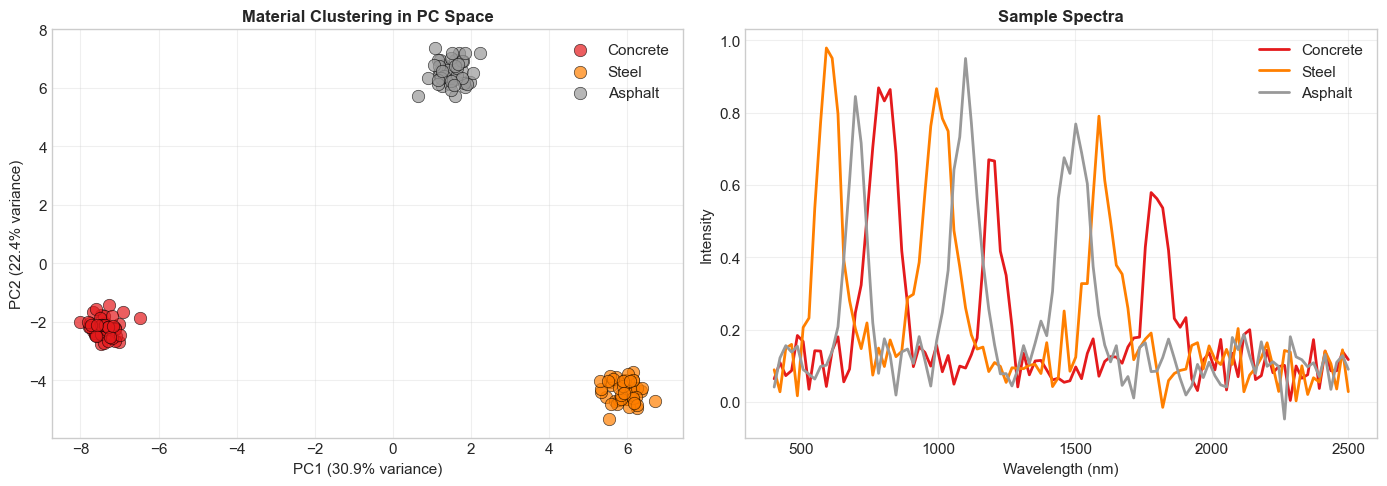


✅ Materials clearly separated in PC space!
   First 2 PCs explain 53.3% of variance

💡 CE Application:
   - Reduce 100 wavelengths → 2-3 PCs
   - Fast material classification
   - Compression ratio: 50.0x


In [18]:
# Material spectral data
np.random.seed(42)

material_data = material_spectral_data(n_samples=150, n_wavelengths=100, 
                                       n_materials=3, random_state=42)
X_material = material_data['X']
y_material = material_data['y']
wavelengths = material_data['wavelengths']
material_names = material_data['material_names']

print("=" * 60)
print("MATERIAL SPECTRAL ANALYSIS")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"   Samples: {X_material.shape[0]}")
print(f"   Wavelengths: {X_material.shape[1]}")
print(f"   Materials: {len(material_names)}")

# PCA
pca_material = pca_svd(X_material, n_components=3)

# Scree plot
fig, ax = plot_scree(pca_material, threshold=0.95, figsize=(14, 5))
plt.show()

# 2D projection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC space
ax = axes[0]
Z_material = transform_pca(X_material, pca_material)
colors = plt.cm.Set1(np.linspace(0, 1, len(material_names)))

for i, name in enumerate(material_names):
    mask = y_material == i
    ax.scatter(Z_material[mask, 0], Z_material[mask, 1], c=[colors[i]], 
              s=80, alpha=0.7, edgecolors='black', linewidth=0.5, label=name)

var1 = pca_material['explained_variance_ratio'][0]
var2 = pca_material['explained_variance_ratio'][1]
ax.set_xlabel(f'PC1 ({var1*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var2*100:.1f}% variance)', fontsize=11)
ax.set_title('Material Clustering in PC Space', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Sample spectra
ax = axes[1]
for i, name in enumerate(material_names):
    mask = y_material == i
    sample_idx = np.where(mask)[0][0]
    ax.plot(wavelengths, X_material[sample_idx], linewidth=2, label=name, color=colors[i])

ax.set_xlabel('Wavelength (nm)', fontsize=11)
ax.set_ylabel('Intensity', fontsize=11)
ax.set_title('Sample Spectra', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Materials clearly separated in PC space!")
print(f"   First 2 PCs explain {np.sum(pca_material['explained_variance_ratio'][:2])*100:.1f}% of variance")
print(f"\n💡 CE Application:")
print(f"   - Reduce 100 wavelengths → 2-3 PCs")
print(f"   - Fast material classification")
print(f"   - Compression ratio: {X_material.shape[1]/2:.1f}x")

---
## 16. Summary & Key Takeaways

### Dimensionality Reduction Methods

| Method | Type | Pros | Cons |
|--------|------|------|------|
| **PCA** | Linear | Fast, interpretable loadings | Only linear relationships |
| **Autoencoders** | Nonlinear | Captures complex manifolds | Requires training, less interpretable |

### When to Use Each

**Use PCA when:**
- ✅ Data has linear structure
- ✅ Need fast computation
- ✅ Want some interpretability
- ✅ Have limited data

**Use Autoencoders when:**
- ✅ Data has nonlinear structure
- ✅ Have lots of data
- ✅ Can afford training time
- ✅ Interpretability less critical

### Curse of Dimensionality

**Key Problems:**
1. Data becomes sparse
2. Distances become meaningless
3. Exponential sampling requirements
4. Overfitting risk

**Solutions:**
- Dimensionality reduction (PCA, autoencoders)
- Feature selection
- Regularization
- Domain knowledge

### Interpretability Tradeoff

**Remember:**
- Compression ↔ Interpretability
- PCs are hard to interpret directly
- Analyze loadings for insights
- Use original features when interpretability critical

### CE Applications

1. **Bridge SHM**: Sensor compression, mode identification
2. **Material Testing**: Spectral data reduction
3. **Traffic Monitoring**: Feature compression
4. **Structural Analysis**: DOF reduction

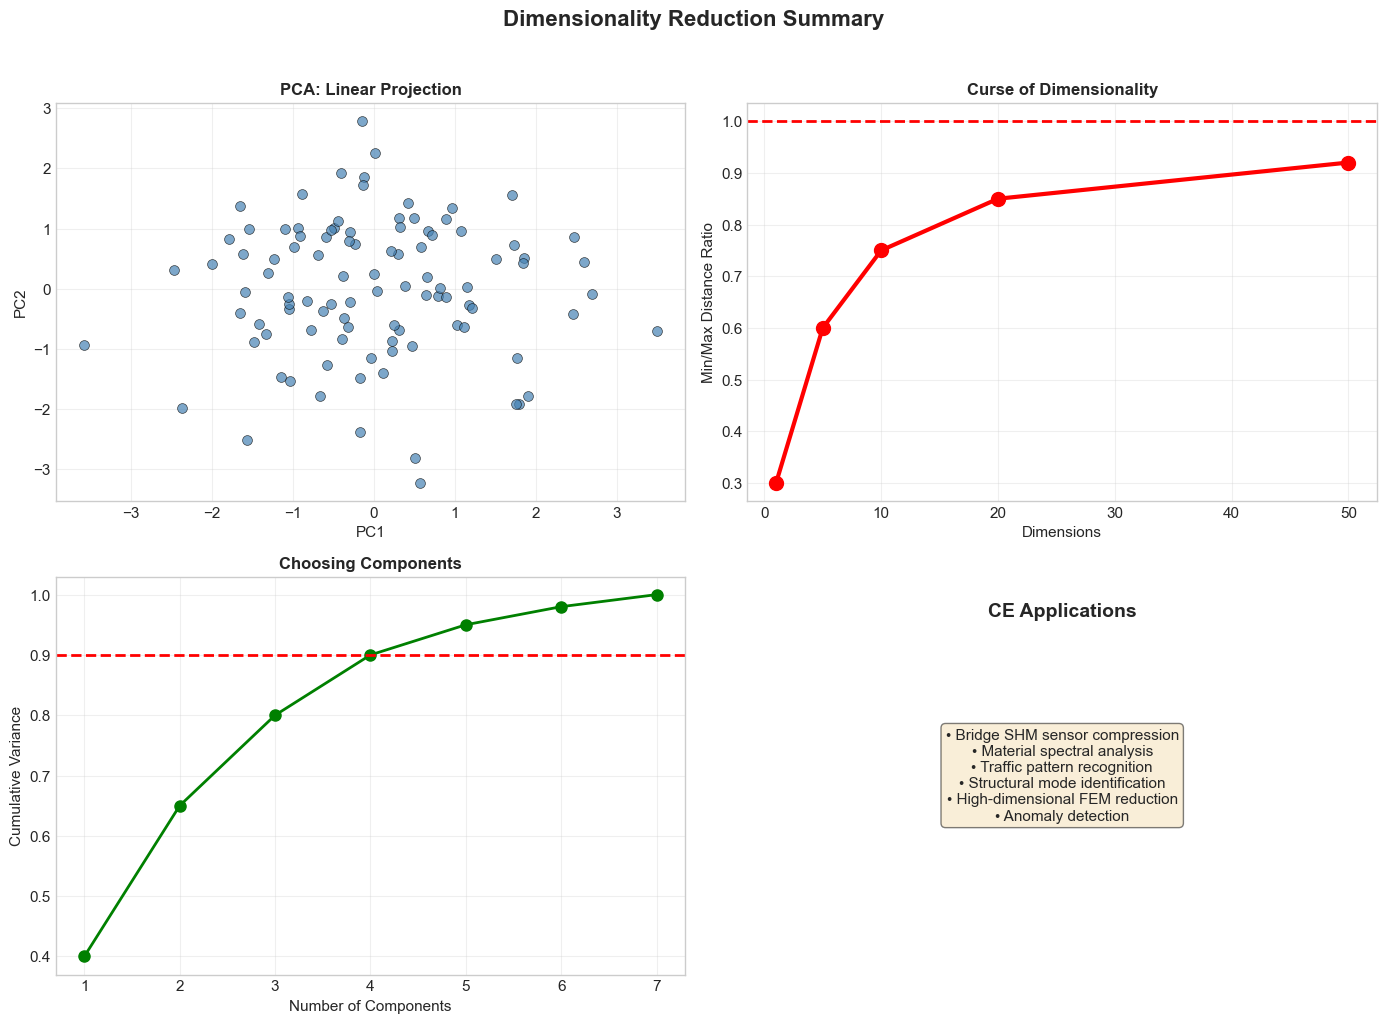


🎓 LECTURE 09 COMPLETE: Dimensionality Reduction

📚 Key Concepts Covered:
   ✅ PCA (Covariance + SVD methods)
   ✅ Autoencoders (Linear + Nonlinear)
   ✅ Curse of Dimensionality
   ✅ Interpretability Tradeoffs
   ✅ CE Applications

🔬 Next Steps:
   1. Practice with interactive widgets
   2. Apply to your own CE datasets
   3. Experiment with different # of components
   4. Compare PCA vs Autoencoders

📖 Next Lecture: Feedforward Neural Networks


In [19]:
# Final summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PCA summary
ax = axes[0, 0]
np.random.seed(42)
X_summary = np.random.randn(100, 10)
pca_summary = pca_svd(X_summary, n_components=2)
Z_summary = transform_pca(X_summary, pca_summary)
ax.scatter(Z_summary[:, 0], Z_summary[:, 1], c='steelblue', s=50, 
          alpha=0.7, edgecolors='black', linewidth=0.5)
ax.set_title('PCA: Linear Projection', fontsize=12, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True, alpha=0.3)

# Curse of dimensionality
ax = axes[0, 1]
dims = [1, 5, 10, 20, 50]
ratios = [0.3, 0.6, 0.75, 0.85, 0.92]
ax.plot(dims, ratios, 'ro-', linewidth=3, markersize=10)
ax.axhline(1.0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Dimensions')
ax.set_ylabel('Min/Max Distance Ratio')
ax.set_title('Curse of Dimensionality', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Scree plot
ax = axes[1, 0]
var_ratios = np.array([0.4, 0.25, 0.15, 0.1, 0.05, 0.03, 0.02])
cumsum = np.cumsum(var_ratios)
ax.plot(range(1, len(cumsum)+1), cumsum, 'go-', linewidth=2, markersize=8)
ax.axhline(0.9, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance')
ax.set_title('Choosing Components', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Applications
ax = axes[1, 1]
ax.text(0.5, 0.9, 'CE Applications', fontsize=14, fontweight='bold',
       ha='center', transform=ax.transAxes)
applications = [
    '• Bridge SHM sensor compression',
    '• Material spectral analysis',
    '• Traffic pattern recognition',
    '• Structural mode identification',
    '• High-dimensional FEM reduction',
    '• Anomaly detection'
]
ax.text(0.5, 0.5, '\n'.join(applications), fontsize=11,
       ha='center', va='center', transform=ax.transAxes,
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.axis('off')

plt.suptitle('Dimensionality Reduction Summary', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("🎓 LECTURE 09 COMPLETE: Dimensionality Reduction")
print("=" * 60)
print("\n📚 Key Concepts Covered:")
print("   ✅ PCA (Covariance + SVD methods)")
print("   ✅ Autoencoders (Linear + Nonlinear)")
print("   ✅ Curse of Dimensionality")
print("   ✅ Interpretability Tradeoffs")
print("   ✅ CE Applications")
print("\n🔬 Next Steps:")
print("   1. Practice with interactive widgets")
print("   2. Apply to your own CE datasets")
print("   3. Experiment with different # of components")
print("   4. Compare PCA vs Autoencoders")
print("\n📖 Next Lecture: Feedforward Neural Networks")